# Newton's Method and the Hessian

Optimizing functions of several variables: from the **gradient** (first derivatives) to the
**Hessian** (second derivatives), and how Newton's method uses both to find minima fast.

We use the running example

$$
f(x,y)=x^4+0.8\,y^4+4x^2+2y^2-xy-0.2\,x^2y .
$$

This is the same bowl-shaped surface you saw in the lecture slide. By the end you will be able to:

- build the **gradient** $\nabla f$ and the **Hessian** $H_f$ of a multivariable function,
- explain what each second derivative means geometrically,
- run **Newton's method** by hand and in Python,
- understand *why* Newton converges so much faster than gradient descent near a minimum,
- classify critical points (min / max / saddle) using the Hessian.


## 2. Theory

### 2.1 The gradient

For $f:\mathbb{R}^n\to\mathbb{R}$ the **gradient** is the vector of first partial derivatives:

$$
\nabla f(x,y)=
\begin{bmatrix}
\dfrac{\partial f}{\partial x}\\[2mm]
\dfrac{\partial f}{\partial y}
\end{bmatrix}.
$$

It points in the direction of **steepest increase**; at a minimum it is the zero vector.

### 2.2 The Hessian

The **Hessian** is the matrix of all second partial derivatives:

$$
H_f(x,y)=
\begin{bmatrix}
\dfrac{\partial^2 f}{\partial x^2} & \dfrac{\partial^2 f}{\partial x\,\partial y}\\[3mm]
\dfrac{\partial^2 f}{\partial y\,\partial x} & \dfrac{\partial^2 f}{\partial y^2}
\end{bmatrix}.
$$

If the second derivatives are continuous, the mixed partials are equal
($\partial^2 f/\partial x\partial y=\partial^2 f/\partial y\partial x$), so the Hessian is **symmetric**.

It is the multivariable generalization of the single-variable second derivative $f''(x)$:
it measures **curvature in every direction**.

### 2.3 Newton's method

Single variable, solving $f'(x)=0$:

$$
x_{k+1}=x_k-\frac{f'(x_k)}{f''(x_k)} .
$$

Several variables, solving $\nabla f=\mathbf{0}$ — replace "divide by $f''$" with "multiply by the
**inverse Hessian**":

$$
\boxed{\;\mathbf{x}_{k+1}=\mathbf{x}_k-H_f(\mathbf{x}_k)^{-1}\,\nabla f(\mathbf{x}_k)\;}
$$

Compare with gradient descent, which uses a scalar step size $\alpha$ instead of $H^{-1}$:

$$
\mathbf{x}_{k+1}=\mathbf{x}_k-\alpha\,\nabla f(\mathbf{x}_k).
$$

Newton replaces the guessed $\alpha$ with the *exact* local curvature information $H^{-1}$.


## 3. Worked example — building $\nabla f$ and $H_f$ by hand

$$
f(x,y)=x^4+0.8\,y^4+4x^2+2y^2-xy-0.2\,x^2y
$$

**First derivatives (gradient).** Differentiate treating the other variable as a constant:

$$
\frac{\partial f}{\partial x}=4x^3+8x-y-0.4\,xy,
\qquad
\frac{\partial f}{\partial y}=3.2\,y^3+4y-x-0.2\,x^2 .
$$

**Second derivatives (Hessian).** Differentiate the gradient again:

$$
\frac{\partial^2 f}{\partial x^2}=12x^2+8-0.4\,y,\qquad
\frac{\partial^2 f}{\partial y^2}=9.6\,y^2+4,
$$

$$
\frac{\partial^2 f}{\partial x\,\partial y}=\frac{\partial^2 f}{\partial y\,\partial x}=-1-0.4\,x .
$$

So

$$
H_f(x,y)=
\begin{bmatrix}
12x^2+8-0.4y & -1-0.4x\\
-1-0.4x & 9.6y^2+4
\end{bmatrix}.
$$

These are exactly the expressions from the lecture's derivative tree. Next we confirm them with SymPy.


In [1]:
import sympy as sp

x, y = sp.symbols('x y', real=True)

f = x**4 + sp.Rational(8,10)*y**4 + 4*x**2 + 2*y**2 - x*y - sp.Rational(2,10)*x**2*y

# Gradient
grad = sp.Matrix([sp.diff(f, x), sp.diff(f, y)])

# Hessian
H = sp.hessian(f, (x, y))

print("f(x, y) =", f)
print("\nGradient:")
sp.pprint(grad)
print("\nHessian:")
sp.pprint(H)


f(x, y) = x**4 - x**2*y/5 + 4*x**2 - x*y + 4*y**4/5 + 2*y**2

Gradient:
⎡   3   2⋅x⋅y          ⎤
⎢4⋅x  - ───── + 8⋅x - y⎥
⎢         5            ⎥
⎢                      ⎥
⎢   2           3      ⎥
⎢  x        16⋅y       ⎥
⎢- ── - x + ───── + 4⋅y⎥
⎣  5          5        ⎦

Hessian:
⎡    2   2⋅y        2⋅x    ⎤
⎢12⋅x  - ─── + 8  - ─── - 1⎥
⎢         5          5     ⎥
⎢                          ⎥
⎢                     2    ⎥
⎢     2⋅x         48⋅y     ⎥
⎢   - ─── - 1     ───── + 4⎥
⎣      5            5      ⎦


The symbolic output matches our hand calculation exactly:

- gradient components $4x^3+8x-y-0.4xy$ and $3.2y^3+4y-x-0.2x^2$,
- Hessian diagonal $12x^2+8-0.4y$ and $9.6y^2+4$, off-diagonal $-1-0.4x$.


## 4. Visualizing the function

Let's reproduce the surface from the slide and its contour map, so we can *see* the bowl we are
about to find the bottom of.


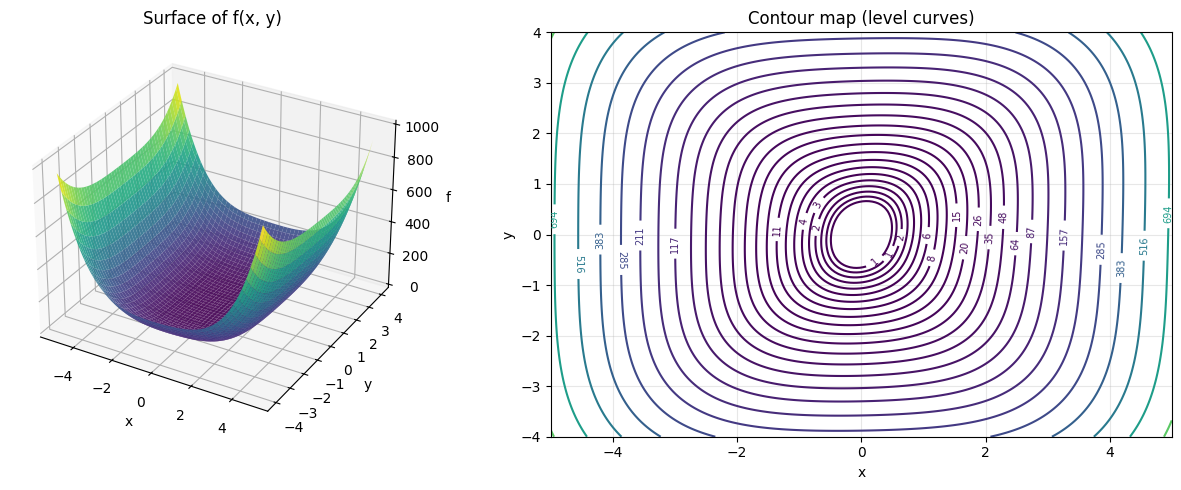

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f_num(x, y):
    return x**4 + 0.8*y**4 + 4*x**2 + 2*y**2 - x*y - 0.2*x**2*y

xs = np.linspace(-5, 5, 200)
ys = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(xs, ys)
Z = f_num(X, Y)

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9)
ax1.set_title("Surface of f(x, y)")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("f")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(X, Y, Z, levels=np.logspace(0, 3.1, 25), cmap='viridis')
ax2.clabel(cs, inline=True, fontsize=7, fmt="%.0f")
ax2.set_title("Contour map (level curves)")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Python: numeric gradient and Hessian

We turn the symbolic expressions into fast numeric functions with `sympy.lambdify`.


In [3]:
grad_fn = sp.lambdify((x, y), grad, 'numpy')
H_fn    = sp.lambdify((x, y), H, 'numpy')

def gradient(p):
    return np.array(grad_fn(p[0], p[1]), dtype=float).reshape(2)

def hessian(p):
    return np.array(H_fn(p[0], p[1]), dtype=float).reshape(2, 2)

# Evaluate at a sample point
p = np.array([3.0, 2.0])
print("point      :", p)
print("gradient   :", gradient(p))
print("Hessian    :\n", hessian(p))


point      : [3. 2.]
gradient   : [127.6  28.8]
Hessian    :
 [[115.2  -2.2]
 [ -2.2  42.4]]


## 6. Newton's method in Python

We iterate

$$
\mathbf{x}_{k+1}=\mathbf{x}_k-H_f(\mathbf{x}_k)^{-1}\,\nabla f(\mathbf{x}_k).
$$

In code we **solve** the linear system $H\,\Delta=\nabla f$ rather than forming the inverse
explicitly — it is more stable and is what real solvers do.


In [4]:
def newton(start, tol=1e-10, max_iter=50):
    p = np.array(start, dtype=float)
    history = [p.copy()]
    for k in range(max_iter):
        g = gradient(p)
        Hk = hessian(p)
        step = np.linalg.solve(Hk, g)   # solve H @ step = g
        p = p - step
        history.append(p.copy())
        if np.linalg.norm(g) < tol:
            break
    return p, np.array(history)

minimum, hist = newton([3.0, 2.0])

print(f"Converged to: x = {minimum[0]:.8f}, y = {minimum[1]:.8f}")
print(f"f(min)      = {f_num(*minimum):.8f}")
print(f"gradient    = {gradient(minimum)}  (should be ~0)")
print(f"iterations  = {len(hist) - 1}")


Converged to: x = 0.00000000, y = 0.00000000
f(min)      = 0.00000000
gradient    = [0. 0.]  (should be ~0)
iterations  = 8


In [5]:
# Print the convergence path
print(f"{'iter':>4} | {'x':>12} | {'y':>12} | {'f(x,y)':>12} | {'|grad|':>10}")
print("-" * 62)
for k, pt in enumerate(hist):
    g = np.linalg.norm(gradient(pt))
    print(f"{k:>4} | {pt[0]:>12.6f} | {pt[1]:>12.6f} | {f_num(*pt):>12.6f} | {g:>10.2e}")


iter |            x |            y |       f(x,y) |     |grad|
--------------------------------------------------------------
   0 |     3.000000 |     2.000000 |   128.200000 |   1.31e+02
   1 |     1.878278 |     1.262552 |    28.516566 |   4.03e+01
   2 |     1.070388 |     0.727842 |     6.233779 |   1.28e+01
   3 |     0.463956 |     0.319311 |     0.957699 |   3.83e+00
   4 |     0.076581 |     0.051439 |     0.024791 |   5.76e-01
   5 |     0.000249 |    -0.000011 |     0.000000 |   2.03e-03
   6 |    -0.000000 |    -0.000000 |     0.000000 |   1.25e-08
   7 |    -0.000000 |    -0.000000 |     0.000000 |   3.05e-19
   8 |     0.000000 |     0.000000 |     0.000000 |   0.00e+00


Notice the `|grad|` column collapsing toward zero extremely fast — roughly **doubling the number
of correct digits each step**. That is the hallmark *quadratic convergence* of Newton's method.


## 7. Newton vs. gradient descent

Let's run plain gradient descent from the same start and compare how many steps each needs.


In [6]:
def gradient_descent(start, alpha=0.01, tol=1e-6, max_iter=10000):
    p = np.array(start, dtype=float)
    history = [p.copy()]
    for k in range(max_iter):
        g = gradient(p)
        p = p - alpha * g
        history.append(p.copy())
        if np.linalg.norm(g) < tol:
            break
    return p, np.array(history)

gd_min, gd_hist = gradient_descent([3.0, 2.0], alpha=0.01)

print(f"Newton           : {len(hist) - 1:>5} steps -> {minimum}")
print(f"Gradient descent : {len(gd_hist) - 1:>5} steps -> {gd_min}")


Newton           :     8 steps -> [0. 0.]
Gradient descent :   399 steps -> [5.67045987e-08 2.40204503e-07]


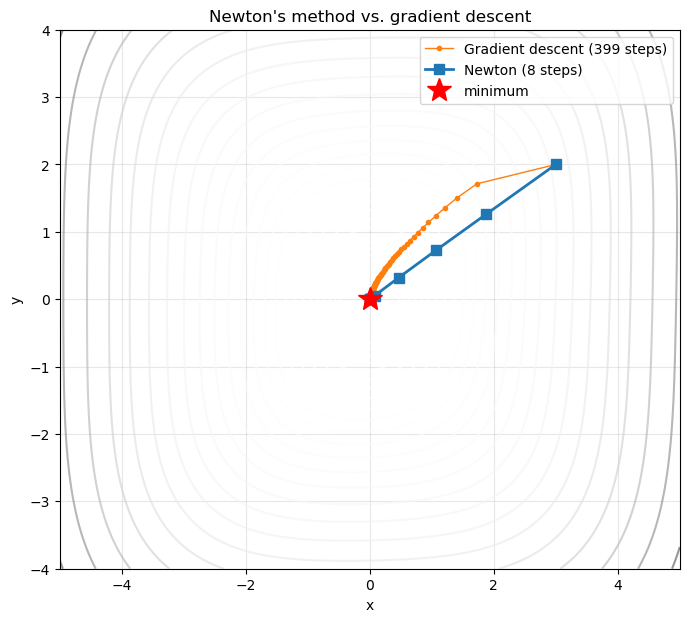

In [7]:
# Visualize both paths on the contour map
fig, ax = plt.subplots(figsize=(8, 7))
cs = ax.contour(X, Y, Z, levels=np.logspace(0, 3.1, 25), cmap='Greys', alpha=0.6)

ax.plot(gd_hist[:, 0], gd_hist[:, 1], 'o-', color='tab:orange',
        ms=3, lw=1, label=f'Gradient descent ({len(gd_hist)-1} steps)')
ax.plot(hist[:, 0], hist[:, 1], 's-', color='tab:blue',
        ms=7, lw=2, label=f'Newton ({len(hist)-1} steps)')
ax.plot(*minimum, 'r*', ms=18, label='minimum')

ax.set_title("Newton's method vs. gradient descent")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


**What you see:** gradient descent takes a long curved trail of small steps, while Newton
takes a handful of large, well-aimed jumps straight into the basin. Newton "knows" the curvature,
so it scales each step correctly.

**The trade-off:** every Newton step costs an $H^{-1}$ (an $n\times n$ linear solve). For large
$n$ that is expensive, which is why ML often uses *quasi-Newton* methods (L-BFGS) that approximate
the Hessian.


## 8. Classifying critical points with the Hessian

At a point where $\nabla f=\mathbf{0}$, the **eigenvalues of the Hessian** tell you what kind of
critical point it is:

| Hessian (at a critical point) | Eigenvalues | Type |
|---|---|---|
| positive definite | all $>0$ | local **minimum** (bowl up) |
| negative definite | all $<0$ | local **maximum** (bowl down) |
| indefinite | mixed signs | **saddle** point |

For a 2×2 Hessian there is a handy shortcut using the determinant
$D=f_{xx}f_{yy}-f_{xy}^2$:

- $D>0$ and $f_{xx}>0$ → minimum,
- $D>0$ and $f_{xx}<0$ → maximum,
- $D<0$ → saddle.


In [8]:
H_min = hessian(minimum)
eigvals = np.linalg.eigvalsh(H_min)

print("Hessian at the solution:\n", H_min)
print("\nEigenvalues:", eigvals)

D = H_min[0, 0] * H_min[1, 1] - H_min[0, 1] * H_min[1, 0]
print(f"\ndeterminant D = {D:.4f}, f_xx = {H_min[0,0]:.4f}")

if np.all(eigvals > 0):
    print("=> positive definite -> LOCAL MINIMUM (confirmed)")
elif np.all(eigvals < 0):
    print("=> negative definite -> local maximum")
else:
    print("=> indefinite -> saddle point")


Hessian at the solution:
 [[ 8. -1.]
 [-1.  4.]]

Eigenvalues: [3.76393202 8.23606798]

determinant D = 31.0000, f_xx = 8.0000
=> positive definite -> LOCAL MINIMUM (confirmed)


Both eigenvalues are positive, so the Hessian is positive definite: the point Newton found is a
genuine **local minimum** — consistent with the bowl shape of the surface.


## 9. Exercises

### Basic
1. By hand, compute the gradient and Hessian of $g(x,y)=x^2+3y^2-xy$. Verify with SymPy.
2. Evaluate the Hessian of our $f$ at the point $(0,0)$. Is it positive definite?

### Intermediate
3. Run Newton's method from a different start, e.g. $(-4,\,3)$. Does it reach the same minimum?
   How many steps?
4. Change gradient descent's learning rate to `alpha=0.03` and then `alpha=0.05`. What happens,
   and how does the Hessian's largest eigenvalue relate to the largest *stable* step size?

### Advanced
5. Construct a function with a **saddle point** (try $h(x,y)=x^2-y^2$) and show, via the Hessian
   eigenvalues, that Newton's method is attracted to the saddle rather than a minimum. Explain why
   this is a known weakness of pure Newton's method.
6. Implement a *damped* Newton step $\mathbf{x}_{k+1}=\mathbf{x}_k-t\,H^{-1}\nabla f$ with a line
   search on $t\in(0,1]$, and discuss why damping improves robustness far from the minimum.


## 10. Solutions / checks

Run the cell below to check exercises 1 and 3.


In [9]:
# Exercise 1 check
g_sym = x**2 + 3*y**2 - x*y
print("g gradient:")
sp.pprint(sp.Matrix([sp.diff(g_sym, x), sp.diff(g_sym, y)]))
print("g Hessian:")
sp.pprint(sp.hessian(g_sym, (x, y)))

# Exercise 3 check: Newton from a different start
m2, h2 = newton([-4.0, 3.0])
print(f"\nNewton from (-4, 3): converged to {m2} in {len(h2)-1} steps")


g gradient:
⎡2⋅x - y ⎤
⎢        ⎥
⎣-x + 6⋅y⎦
g Hessian:
⎡2   -1⎤
⎢      ⎥
⎣-1  6 ⎦

Newton from (-4, 3): converged to [-6.22404943e-25 -7.83559760e-25] in 8 steps


## 11. Conclusion

- The **gradient** $\nabla f$ collects first derivatives — it points downhill.
- The **Hessian** $H_f$ collects second derivatives — it measures **curvature** and is symmetric.
- **Newton's method**, $\mathbf{x}_{k+1}=\mathbf{x}_k-H_f^{-1}\nabla f$, uses both and converges
  **quadratically** near a minimum — far faster than gradient descent's fixed-step crawl.
- The **eigenvalues of the Hessian** classify critical points: all positive → minimum,
  all negative → maximum, mixed → saddle.
- The price is computing and inverting the Hessian each step; large problems use quasi-Newton
  approximations instead.

> Done — this notebook covers theory, the worked $f(x,y)$ example, SymPy derivations,
> visualizations, a Newton-vs-gradient-descent comparison, and exercises.
